<a href="https://colab.research.google.com/github/ldc902/predicting-house-prices/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.impute import KNNImputer

import pickle
!pip install gower
import gower

# 1. Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ds = pd.read_csv('/content/drive/MyDrive/colab-notebooks/predicting-house-prices/dataset/housing.csv')
ds

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
ds.shape  # 2D Dataframe: (rows, columns)

(20640, 10)

# 1.1. Data type

In [5]:
for col in ds.columns:
    print(f"\n===== {col} =====")
    print(ds[col].map(type).unique())


===== longitude =====
[<class 'float'>]

===== latitude =====
[<class 'float'>]

===== housing_median_age =====
[<class 'float'>]

===== total_rooms =====
[<class 'float'>]

===== total_bedrooms =====
[<class 'float'>]

===== population =====
[<class 'float'>]

===== households =====
[<class 'float'>]

===== median_income =====
[<class 'float'>]

===== median_house_value =====
[<class 'float'>]

===== ocean_proximity =====
[<class 'str'>]


In [6]:
ds["ocean_proximity"] = ds["ocean_proximity"].apply(
  lambda val: str(val).strip().lower() if pd.notnull(val) else val
)

In [7]:
numeric_cols = ds.select_dtypes(include="number").columns

for col_name in numeric_cols:
  ds[col_name] = pd.to_numeric(ds[col_name], errors='coerce') # invalid thành NaN

# 1.2. Processing

In [8]:
ds[numeric_cols].isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0


In [9]:
ds["ocean_proximity"].isnull().sum()

np.int64(0)

In [10]:
ds["ocean_proximity"].unique().tolist()

['near bay', '<1h ocean', 'inland', 'near ocean', 'island']

In [11]:
ocp_onehot_encoder = OneHotEncoder(sparse_output=False) # encode nhị phân

X_ocp = ocp_onehot_encoder.fit_transform(ds[['ocean_proximity']]) # fit và transform

onehot_ocp_col_names = ocp_onehot_encoder.get_feature_names_out(['ocean_proximity'])

X_ocp = pd.DataFrame(
    X_ocp,
    columns = onehot_ocp_col_names,
    index = ds.index
)

ds = pd.concat([ds, X_ocp], axis=1)

# 1.2.1. Split

In [12]:
Y = ds[["median_house_value"]]

X = ds.drop(['median_house_value'], axis=1)

In [13]:
X_train, X_remain, Y_train, Y_remain = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=123)  # 20% remain

ratio_test_to_remain = 0.01 / 0.19  # test_length/remain_length; 1% và 19% của ds

X_val, X_test, Y_val, Y_test = train_test_split(X_remain, Y_remain, test_size=ratio_test_to_remain, shuffle=True, random_state=123)

In [14]:
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

Y_train = Y_train.reset_index(drop=True)
Y_val = Y_val.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

# 1.2.2. KNNImputer
-nếu đưa ocean_proximity vào KNNImputer, dùng khoảng cách gower thay vì Euclidean

In [15]:
k = 5
eps = 1e-8  # Tránh chia cho 0

def fill_na(target_ds):

    na_rows = target_ds[target_ds["total_bedrooms"].isna()]  # idx ko thay đổi

    if na_rows.empty:
        return

    notna_rows = X_train[X_train["total_bedrooms"].notna()]

    gower_matrix = gower.gower_matrix(
          na_rows.drop(columns=["total_bedrooms", *onehot_ocp_col_names]),
          notna_rows.drop(columns=["total_bedrooms", *onehot_ocp_col_names])
    )

    for idx, na_distances in enumerate(gower_matrix):
        nearest_idxs_in_notna_rows = np.argsort(na_distances)[:k]

        nearest_df_idxs = notna_rows.iloc[nearest_idxs_in_notna_rows].index  # sx theo giá trị và trả lại idxs ban đầu


        # pp Weighted Mean

        neighbor_values = notna_rows.iloc[nearest_idxs_in_notna_rows]["total_bedrooms"].to_numpy()

        neighbor_distances = na_distances[nearest_idxs_in_notna_rows]

        weights = 1 / (neighbor_distances + eps)

        imputed_value = np.sum(weights * neighbor_values) / np.sum(weights)
        # c2
        # imputed_value = np.average(
        #     neighbor_values,
        #     weights=weights
        # )

        target_ds.loc[na_rows.index[idx], "total_bedrooms"] = imputed_value

In [16]:
fill_na(X_train)
fill_na(X_val)
fill_na(X_test)

In [17]:
X_train = X_train.drop(columns = ["ocean_proximity"])

X_val = X_val.drop(columns = ["ocean_proximity"])

X_test = X_test.drop(columns = ["ocean_proximity"])

# 1.2.3. Scale
-chỉ scale sau khi đã split

In [18]:
ocp_cols_train = X_train[onehot_ocp_col_names]
ocp_cols_val = X_val[onehot_ocp_col_names]
ocp_cols_test = X_test[onehot_ocp_col_names]

In [19]:
normal_col_names = [
    "longitude",
    "latitude",
    "housing_median_age",
    "median_income"
]

skew_col_names = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]

X_standard_scaler = StandardScaler()
X_robust_scaler = RobustScaler()
Y_standard_scaler = StandardScaler()

data_preprocessor = ColumnTransformer([
    ("standard", X_standard_scaler, normal_col_names),
    ("robust", X_robust_scaler, skew_col_names),
])

In [20]:
X_train_cols_rest = pd.DataFrame(     # DataFrame (-1, 8)
    data_preprocessor.fit_transform(X_train.drop(columns=onehot_ocp_col_names)),  # fit và transform
    columns=X_train.drop(columns=onehot_ocp_col_names).columns,
    index=X_train.index
)

X_val_cols_rest = pd.DataFrame(
    data_preprocessor.transform(X_val.drop(columns=onehot_ocp_col_names)),  # transform
    columns=X_val.drop(columns=onehot_ocp_col_names).columns,
    index=X_val.index
)

X_test_cols_rest = pd.DataFrame(
    data_preprocessor.transform(X_test.drop(columns=onehot_ocp_col_names)),
    columns=X_test.drop(columns=onehot_ocp_col_names).columns,
    index=X_test.index
)

In [21]:
X_train = pd.concat([X_train_cols_rest, ocp_cols_train], axis=1) # DataFrame (-1, 13)
X_val = pd.concat([X_val_cols_rest, ocp_cols_val], axis=1)
X_test = pd.concat([X_test_cols_rest, ocp_cols_test], axis=1)

In [22]:
Y_train = pd.DataFrame(
    Y_standard_scaler.fit_transform(Y_train),
    columns=Y_train.columns,
    index=Y_train.index
)

Y_val = pd.DataFrame(
    Y_standard_scaler.transform(Y_val),
    columns=Y_val.columns,
    index=Y_val.index
)

Y_test = pd.DataFrame(
    Y_standard_scaler.transform(Y_test),
    columns=Y_test.columns,
    index=Y_test.index
)

In [23]:
ds[numeric_cols] = ds[numeric_cols].astype("float32")

# 2. Model

In [24]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))  # shape=(13,)

model.add(Dense(256))  # linear regression
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.1))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

# output-layer, 1 neuron, linear regression
model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,697 (178.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [25]:
model.compile(optimizer='adam', loss=MeanSquaredError(), metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)

history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=500,
                    batch_size=250,
                    callbacks=[early_stop], verbose=1)

Epoch 1/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 0.5239 - mae: 0.5265 - val_loss: 0.5990 - val_mae: 0.5917
Epoch 2/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3519 - mae: 0.4331 - val_loss: 0.4359 - val_mae: 0.4973
Epoch 3/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3121 - mae: 0.4012 - val_loss: 0.3785 - val_mae: 0.4520
Epoch 4/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3060 - mae: 0.3986 - val_loss: 0.3049 - val_mae: 0.3991
Epoch 5/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2921 - mae: 0.3869 - val_loss: 0.2617 - val_mae: 0.3616
Epoch 6/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2814 - mae: 0.3804 - val_loss: 0.2578 - val_mae: 0.3497
Epoch 7/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2754 - mae: 0.3724 - val_loss: 0.2406 - val_mae: 0.3424
Epoch 8/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2665 - mae: 0.3656 - val_loss: 0.2521 - val_mae: 0.3614
Epoch 9/500
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.26

In [26]:
model_dir_path="/content/drive/MyDrive/colab-notebooks/predicting-house-prices/model"

model.save(f"{model_dir_path}/model.keras")

with open(f'{model_dir_path}/ocp_onehot_encoder.pkl', 'wb') as f1:
    pickle.dump(ocp_onehot_encoder, f1)

with open(f'{model_dir_path}/X_standard_scaler.pkl', 'wb') as f2:
    pickle.dump(data_preprocessor.named_transformers_["standard"], f2)

with open(f'{model_dir_path}/X_robust_scaler.pkl', 'wb') as f3:
    pickle.dump(data_preprocessor.named_transformers_["robust"], f3)

with open(f'{model_dir_path}/Y_standard_scaler.pkl', 'wb') as f4:
    pickle.dump(Y_standard_scaler, f4)

with open(f'{model_dir_path}/data_preprocessor.pkl', 'wb') as f5:
    pickle.dump(data_preprocessor, f5)

# 3. Đánh giá

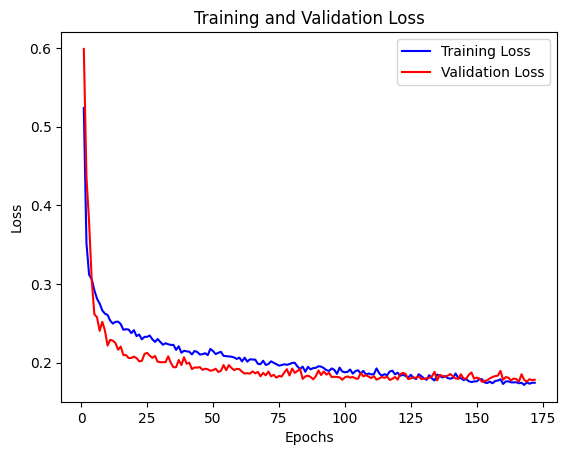

In [27]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


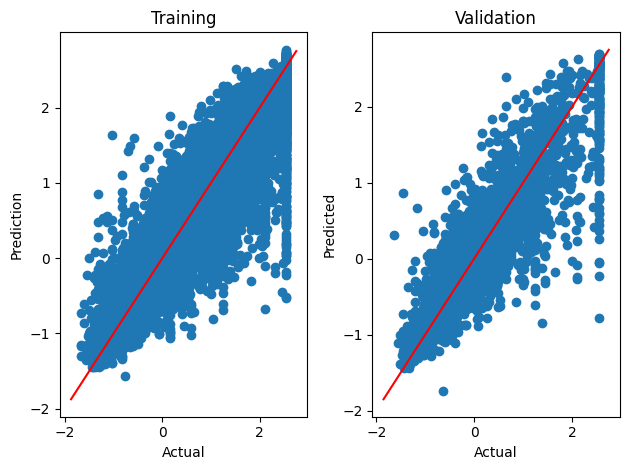

In [28]:
fig, axes = plt.subplots(1,2)

axes[0].scatter(x=Y_train, y=model.predict(X_train))
axes[0].set_xlabel('Actual', fontsize=10)
axes[0].set_ylabel('Prediction', fontsize=10)
axes[0].set_title('Training')

x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')

axes[1].scatter(x=Y_val, y=model.predict(X_val))
axes[1].set_xlabel('Actual', fontsize=10)
axes[1].set_ylabel('Predicted', fontsize=10)
axes[1].set_title('Validation')

x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

fig.tight_layout()
plt.show()

In [29]:
# đánh giá model trên tập test
Y_predict = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, Y_predict))
print("MSE:", mean_squared_error(Y_test, Y_predict))
print("MSLE:", mean_squared_log_error(
    Y_standard_scaler.inverse_transform(Y_test),  # StandardScaler() có thể âm
    Y_standard_scaler.inverse_transform(Y_predict)
))
print("R-Square:", r2_score(Y_test, Y_predict))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
MAE: 0.2459249645471573
MSE: 0.13926441967487335
MSLE: 0.0387612618590199
R-Square: 0.8515512347221375


In [30]:
print(f"Predicted median_house_value:", Y_standard_scaler.inverse_transform(Y_predict)[:10])
print(f"Actual median_house_value:", Y_standard_scaler.inverse_transform(Y_test)[:10])

Predicted median_house_value: [[333056.47 ]
 [186855.34 ]
 [ 85896.89 ]
 [ 62143.418]
 [233940.94 ]
 [275322.28 ]
 [ 84120.43 ]
 [159385.4  ]
 [156304.6  ]
 [111070.11 ]]
Actual median_house_value: [[302000.]
 [222100.]
 [ 54900.]
 [ 60900.]
 [237500.]
 [241000.]
 [ 71400.]
 [ 97100.]
 [160200.]
 [137500.]]
